In [2]:
!pip install matplotlib
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.style.use('ggplot')

In [4]:
df_pres = pd.read_csv('/content/EF-Izquierda-PRD.csv')
df_pres.head()

,Año,Tipo de elección,1991,PRD
0,1991,Senado,17.24,8.18
1,1991,Diputados,17.42,7.91
2,1994,Presidencial,21.20,16.59
3,1994,Senado,21.59,16.32
4,1994,Diputados,21.29,16.12


In [5]:
df_pres['Otros Partidos de Izquierda'] = df_pres['1991'] - df_pres['PRD']
df_pres.head()

,Año,Tipo de elección,1991,PRD,Otros Partidos de Izquierda
0,1991,Senado,17.24,8.18,9.06
1,1991,Diputados,17.42,7.91,9.51
2,1994,Presidencial,21.20,16.59,4.61
3,1994,Senado,21.59,16.32,5.27
4,1994,Diputados,21.29,16.12,5.17


In [6]:
df_PRD = df_pres.iloc[1:, [df_pres.columns.get_loc('Tipo de elección'), -2, -1]]
df_PRD.head()

,Tipo de elección,PRD,Otros Partidos de Izquierda
1,Diputados,7.91,9.51
2,Presidencial,16.59,4.61
3,Senado,16.32,5.27
4,Diputados,16.12,5.17
5,Diputados,24.98,4.82


In [7]:
df_pres[['Otros Partidos de Izquierda', 'PRD']] = df_pres[['Otros Partidos de Izquierda', 'PRD']].apply(pd.to_numeric, errors='coerce')

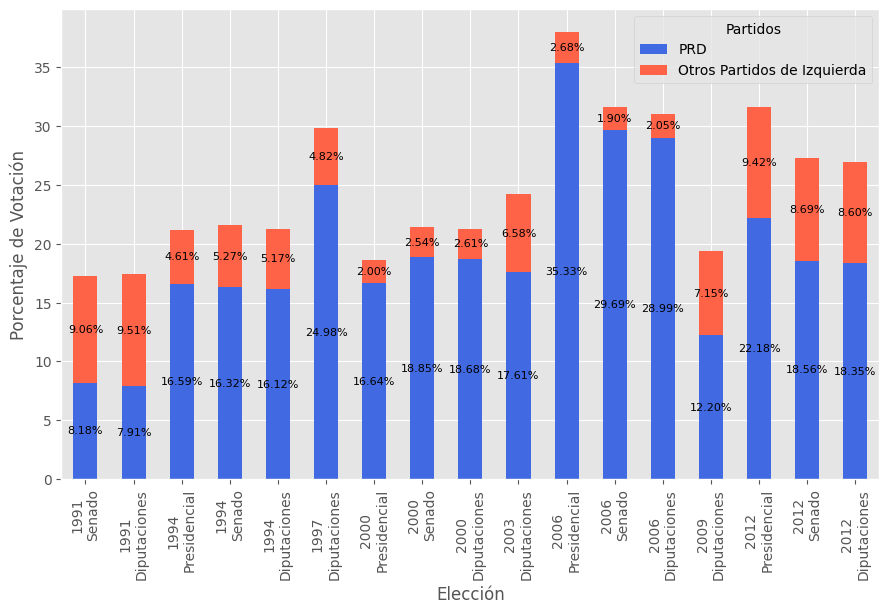

In [23]:
fig, ax = plt.subplots(figsize=(9, 6))
df_pres[['PRD', 'Otros Partidos de Izquierda']].plot(
    kind='bar',
    stacked=True,
    color=['#4169E1', '#FF6347'],
    ax=ax)

xticks = ax.get_xticks()

if 'Año' in df_pres.columns:
    labels = [f"{year}\n{election.replace('Diputados', 'Diputaciones')}" for year, election in zip(df_pres['Año'][xticks.astype(int)], df_pres['Tipo de elección'][xticks.astype(int)])]
else:
   labels = [f"{df_pres.iloc[int(i)].name}\n{df_pres['Tipo de elección'].iloc[int(i)].replace('Diputados', 'Diputaciones')}" for i in xticks]

ax.set_xticklabels(labels)

plt.ylabel('Porcentaje de Votación')
plt.legend(loc='upper right', title='Partidos')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2, p.get_y() + p.get_height() / 2),
                ha='center', va='center', fontsize=8, color='black')

plt.tight_layout()
plt.xlabel("Elección")
plt.savefig('grafico_barras_apiladas.png', dpi=300, bbox_inches='tight')
plt.show()